In [4]:
!unzip "archive (5) (1).zip"

Archive:  archive (5) (1).zip
  inflating: Ad click data.csv       


In [5]:
!ls

'Ad click data.csv'  'archive (5) (1).zip'   sample_data


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

In [7]:
df = pd.read_csv("archive (5) (1).zip")
df.head()

,VistID,Time_Spent,Age,Avg_Income,Internet_Usage,Ad_Topic,Country_Name,City_code,Male,Time_Period,Weekday,Month,Year,Clicked
0,5183153,87.97,43,55901.12,185.46,product_11,Serbia,City_5,No,Mid-Night,Thursday,July,2020,0
1,4023265,51.63,50,39132.00,176.73,product_8,Turkmenistan,City_1,No,Evening,Saturday,June,2020,1
2,4708083,82.37,38,57032.36,210.60,product_6,Northern Mariana Islands,City_2,No,Morning,Tuesday,January,2020,0
3,9771815,62.06,45,48868.00,190.05,product_19,South Africa,City_3,Yes,Morning,Thursday,April,2020,1
4,6451317,77.66,31,61608.23,204.86,product_11,Guadeloupe,City_2,No,Noon,Thursday,January,2020,0


In [8]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6657 entries, 0 to 6656
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   VistID          6657 non-null   int64  
 1   Time_Spent      6657 non-null   float64
 2   Age             6657 non-null   int64  
 3   Avg_Income      6657 non-null   float64
 4   Internet_Usage  6657 non-null   float64
 5   Ad_Topic        6657 non-null   object 
 6   Country_Name    6657 non-null   object 
 7   City_code       6657 non-null   object 
 8   Male            6657 non-null   object 
 9   Time_Period     6657 non-null   object 
 10  Weekday         6657 non-null   object 
 11  Month           6657 non-null   object 
 12  Year            6657 non-null   int64  
 13  Clicked         6657 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 728.2+ KB


Index(['VistID', 'Time_Spent', 'Age', 'Avg_Income', 'Internet_Usage',
       'Ad_Topic', 'Country_Name', 'City_code', 'Male', 'Time_Period',
       'Weekday', 'Month', 'Year', 'Clicked'],
      dtype='object')

In [10]:
df.shape

(6657, 14)

In [12]:
df.isnull().sum()

,0
VistID,0
Time_Spent,0
Age,0
Avg_Income,0
Internet_Usage,0
Ad_Topic,0
Country_Name,0
City_code,0
Male,0
Time_Period,0


In [14]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X = df.drop('Clicked', axis=1)
y = df['Clicked']

In [18]:
df['Clicked'].sum()

np.int64(3038)

In [20]:
df['Clicked'].mean()

np.float64(0.45636172450052576)

In [22]:
df.corr()

,VistID,Time_Spent,Age,Avg_Income,Internet_Usage,Year,Clicked,Ad_Topic_product_10,Ad_Topic_product_11,Ad_Topic_product_12,...,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May
VistID,1.000000,-0.004147,-0.007503,0.017145,-0.000016,NaN,-0.004260,-0.002547,0.008661,0.000243,...,0.010891,0.004985,-0.007812,0.001869,-0.006118,0.022973,-0.017553,0.000192,-0.000800,0.005780
Time_Spent,-0.004147,1.000000,-0.185667,0.364737,0.588360,NaN,-0.712439,0.015099,0.016157,0.018432,...,0.013192,-0.022068,-0.000198,0.011380,-0.005073,0.001570,0.008808,0.002203,0.000889,-0.008519
Age,-0.007503,-0.185667,1.000000,-0.104503,-0.199750,NaN,0.244121,0.018248,-0.018731,-0.002767,...,-0.012900,0.015016,-0.000865,-0.007084,0.015653,-0.003141,0.002849,-0.022297,0.004386,0.002778
Avg_Income,0.017145,0.364737,-0.104503,1.000000,0.383978,NaN,-0.460287,0.003357,-0.012482,-0.002078,...,0.014865,-0.011683,0.020554,-0.014443,0.000259,0.001745,0.003881,-0.003692,0.006519,-0.008963
Internet_Usage,-0.000016,0.588360,-0.199750,0.383978,1.000000,NaN,-0.742764,0.012941,-0.008859,0.031196,...,0.017544,-0.014501,-0.002543,0.013922,-0.010026,0.005994,0.008445,-0.012512,0.011082,-0.021049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Month_January,0.022973,0.001570,-0.003141,0.001745,0.005994,NaN,-0.003296,0.015131,0.007017,0.014691,...,0.016347,-0.005412,-0.005799,-0.016406,-0.169699,1.000000,-0.168230,-0.169385,-0.168230,-0.170327
Month_July,-0.017553,0.008808,0.002849,0.003881,0.008445,NaN,-0.015151,-0.008059,-0.002875,-0.008864,...,-0.019292,-0.012978,0.007954,0.009563,-0.163807,-0.168230,1.000000,-0.163503,-0.162389,-0.164413
Month_June,0.000192,0.002203,-0.022297,-0.003692,-0.012512,NaN,0.003085,-0.011272,0.010871,0.004544,...,-0.001688,-0.004853,-0.008894,0.001368,-0.164931,-0.169385,-0.163503,1.000000,-0.163503,-0.165541
Month_March,-0.000800,0.000889,0.004386,0.006519,0.011082,NaN,-0.014281,0.001392,-0.007766,0.012624,...,-0.015622,0.025838,0.000472,-0.002998,-0.163807,-0.168230,-0.162389,-0.163503,1.000000,-0.164413


In [28]:
X = df.drop('Clicked', axis=1)
y = df['Clicked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [35]:
# Predict on test data
y_pred_lr = model.predict(X_test)
#Accuracy testing
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

Logistic Regression Accuracy: 91.82%


In [36]:
# training random forest model
randomforest = RandomForestClassifier()
randomforest.fit(X_train, y_train)
y_pred_rf = randomforest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [39]:
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

if accuracy_rf > accuracy_lr:
    print("Random Forest improved the accuracy!")
else:
    print("Logistic Regression performed better or equal.")

Random Forest Accuracy: 94.22%
Random Forest improved the accuracy!


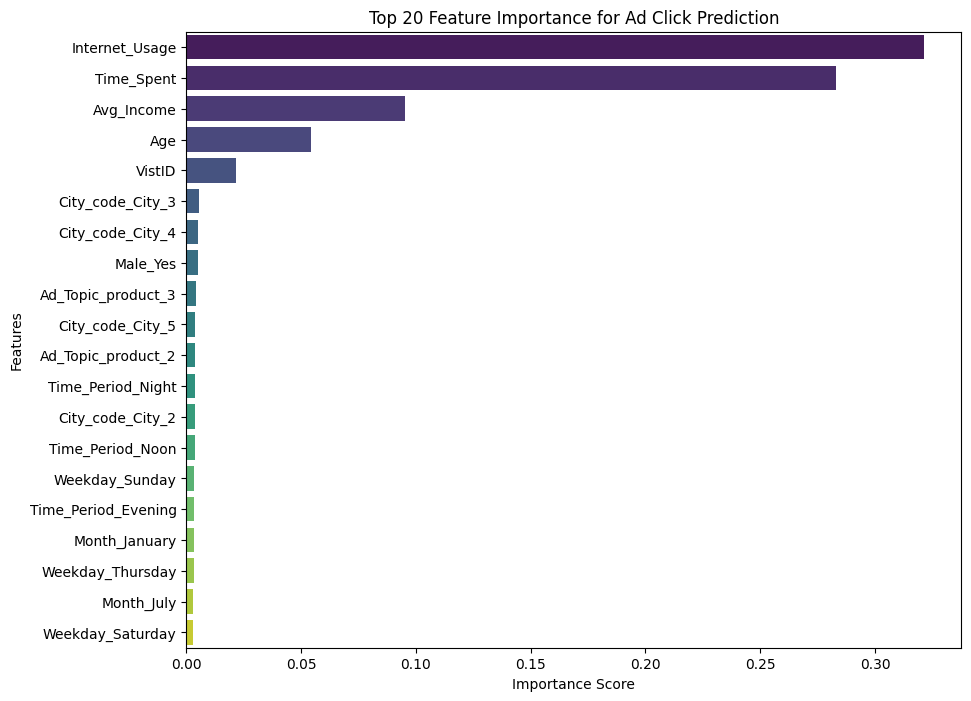

In [40]:
# Feature Importance from Random Forest
featureimportance = pd.Series(randomforest.feature_importances_, index=X.columns)
featureimportance = featureimportance.sort_values(ascending=False)

# Plotting featureimportance
top20features = featureimportance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top20features.values, y=top20features.index,hue=top20features.index, palette='viridis',legend=False)

plt.title('Top 20 Feature Importance for Ad Click Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


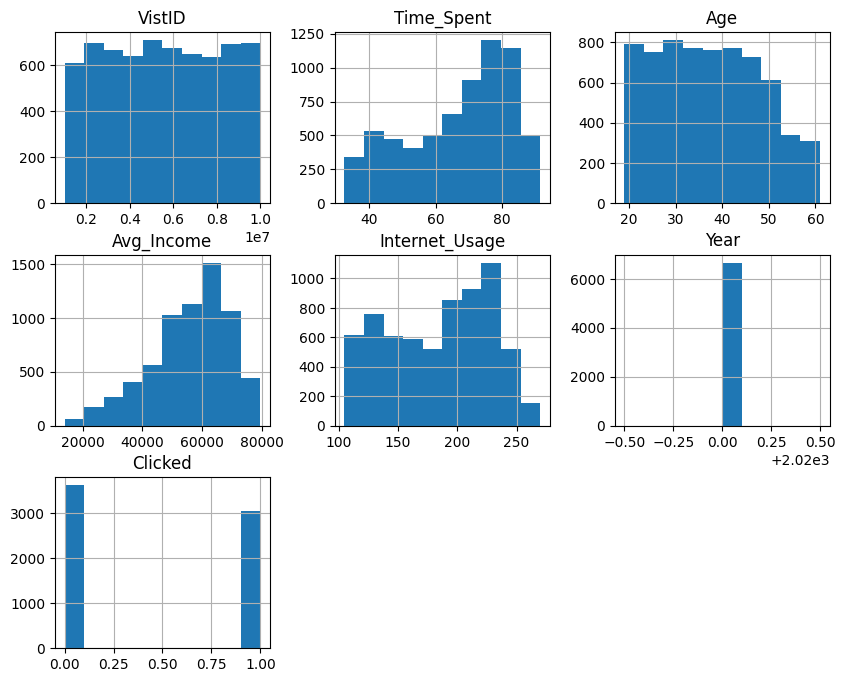

In [41]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

In [42]:
# testing for a new user
new_user_data = pd.DataFrame({'Age': [35], 'Income': [60000],'Daily Internet Usage': [200],'Gender': [1]})
new_user_data = new_user_data.reindex(columns=X.columns, fill_value=0)
# prediction
prediction = randomforest.predict(new_user_data.values)
if prediction[0] == 1:
    print("Prediction: The user will click on this ad")
else:
    print("Prediction: The user will not click on this ad")

Prediction: The user will click on this ad


In [44]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Accuracy: 0.9421921921921922
Random Forest Accuracy: 0.9421921921921922
